```{contents}
```
## Attention

Attention allows a model to **focus selectively** on the most relevant parts of the input sequence when producing each element of the output.

In formal terms, attention computes:

$$
\text{Attention}(Q, K, V) = \text{WeightedSum}(V)
$$
where:

* **Q (Query)** – what we’re trying to find relevance for (e.g., decoder hidden state)
* **K (Key)** – all input representations
* **V (Value)** – same as keys but holding contextual info

Weights are learned via similarity between `Q` and `K`.


### Goal of Attention

Attention learns **how much each input token should “focus” on other tokens** when producing an output.
To do this, every token in a sequence is transformed into three vectors:

* **Q (Query)** → what am I looking for?
* **K (Key)** → what information do I have?
* **V (Value)** → what is the actual content?
  

---

### **Major Types of Attention**

#### Additive Attention (Bahdanau Attention, 2014)

> The original attention mechanism for RNN-based Seq2Seq models.

##### Used In:

Neural Machine Translation (Bahdanau et al., 2014)

##### Mechanism:

* Combines encoder hidden states $h_i$ and decoder state $s_{t-1}$
* Uses a small feed-forward network to learn attention scores.

$$
e_{t,i} = v_a^T \tanh(W_s s_{t-1} + W_h h_i)
$$
$$
\alpha_{t,i} = \text{softmax}(e_{t,i})
$$

Then context vector:

$$
c_t = \sum_i \alpha_{t,i} h_i
$$

##### Advantages:

* Handles long dependencies better than vanilla Seq2Seq
* Works well for smaller hidden dimensions

##### Disadvantage:

* Computationally expensive due to many matrix multiplications.

---

##### Demonstration


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Encoder hidden states (batch_size=1, seq_len=5, hidden_dim=8)
encoder_outputs = torch.randn(1, 5, 8)

# Decoder hidden state (batch_size=1, hidden_dim=8)
decoder_hidden = torch.randn(1, 8)

class AdditiveAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(AdditiveAttention, self).__init__()
        self.W_h = nn.Linear(hidden_dim, hidden_dim)   # transforms encoder states
        self.W_s = nn.Linear(hidden_dim, hidden_dim)   # transforms decoder state
        self.v = nn.Linear(hidden_dim, 1, bias=False)  # final scoring vector

    def forward(self, decoder_hidden, encoder_outputs):
        """
        decoder_hidden: [batch, hidden_dim]
        encoder_outputs: [batch, seq_len, hidden_dim]
        """
        seq_len = encoder_outputs.size(1)

        # Repeat decoder hidden state across the sequence
        decoder_hidden_expanded = decoder_hidden.unsqueeze(1).repeat(1, seq_len, 1)

        # Compute energy scores
        energies = torch.tanh(self.W_h(encoder_outputs) + self.W_s(decoder_hidden_expanded))

        # Apply v^T to get alignment scores (batch, seq_len, 1)
        scores = self.v(energies).squeeze(-1)

        # Apply softmax to get attention weights (alpha)
        attn_weights = F.softmax(scores, dim=1)

        # Weighted sum of encoder outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)

        return context, attn_weights

attention = AdditiveAttention(hidden_dim=8)
context_vector, attention_weights = attention(decoder_hidden, encoder_outputs)

print("Context vector shape:", context_vector.shape)
print("Attention weights shape:", attention_weights.shape)
print("Attention weights (sum to 1):", attention_weights.sum().item())

print("Encoder hidden states:\n", encoder_outputs)
print("\nDecoder hidden state:\n", decoder_hidden)
print("\nAttention weights:\n", attention_weights)
print("\nContext vector:\n", context_vector)


Context vector shape: torch.Size([1, 8])
Attention weights shape: torch.Size([1, 5])
Attention weights (sum to 1): 1.0
Encoder hidden states:
 tensor([[[-0.6535,  0.0849,  2.2073, -0.1183, -1.5439,  2.4324,  1.9092,
          -1.0948],
         [ 0.6221,  1.4152,  1.0472, -1.1514,  1.1278,  0.2311,  1.0926,
           0.7815],
         [-0.1039, -0.4847,  0.6262,  0.4264, -0.5826,  0.7167, -1.4892,
          -0.5280],
         [ 0.9388, -0.2961,  0.3454, -0.5895,  1.0587,  0.0666, -0.6515,
          -0.1223],
         [-0.3757, -1.1562, -0.0465,  0.3718,  2.4603,  0.2695,  0.0264,
           1.9657]]])

Decoder hidden state:
 tensor([[ 0.1359, -0.6924, -1.0591,  1.4122,  1.1770, -0.9597,  1.8146,  0.1815]])

Attention weights:
 tensor([[0.1948, 0.1339, 0.2585, 0.1918, 0.2210]], grad_fn=<SoftmaxBackward0>)

Context vector:
 tensor([[ 0.0261, -0.2316,  0.7881, -0.0979,  0.4465,  0.7624,  0.0142,  0.1659]],
       grad_fn=<SqueezeBackward1>)




#### Multiplicative Attention (Luong Attention, 2015)

> A faster, more memory-efficient variant of Bahdanau’s attention.

##### Mechanism:

* Uses **dot products** instead of feedforward networks.

$$
\text{score}(s_t, h_i) =
\begin{cases}
s_t^\top h_i & \text{(dot)} \
s_t^\top W h_i & \text{(general)} \
(s_t^\top W) h_i & \text{(concat variant)}
\end{cases}
$$

Weights:
$$
\alpha_{t,i} = \text{softmax}(\text{score}(s_t, h_i))
$$
Context:
$$
c_t = \sum_i \alpha_{t,i} h_i
$$

##### Advantages:

* Simpler and faster than additive attention
* Easier to train on GPUs

##### Disadvantage:

* Slightly less flexible for very different input-output spaces.

---

##### Demonstration


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Encoder hidden states: (batch_size=1, seq_len=5, hidden_dim=8)
encoder_outputs = torch.randn(1, 5, 8)

# Decoder hidden state: (batch_size=1, hidden_dim=8)
decoder_hidden = torch.randn(1, 8)

class LuongAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(LuongAttention, self).__init__()
        self.W_a = nn.Linear(hidden_dim, hidden_dim, bias=False)  # learnable weight matrix

    def forward(self, decoder_hidden, encoder_outputs):
        """
        decoder_hidden: [batch, hidden_dim]
        encoder_outputs: [batch, seq_len, hidden_dim]
        """
        # Apply linear transform to encoder outputs
        encoder_transformed = self.W_a(encoder_outputs)  # [batch, seq_len, hidden_dim]

        # Expand decoder hidden across time dimension
        decoder_expanded = decoder_hidden.unsqueeze(1)  # [batch, 1, hidden_dim]

        # Compute alignment scores: dot(decoder, encoder)
        scores = torch.bmm(decoder_expanded, encoder_transformed.transpose(1, 2))  # [batch, 1, seq_len]
        scores = scores.squeeze(1)  # [batch, seq_len]

        # Apply softmax to get attention weights
        attn_weights = F.softmax(scores, dim=1)  # [batch, seq_len]

        # Compute context vector as weighted sum of encoder outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [batch, hidden_dim]

        return context, attn_weights



attention = LuongAttention(hidden_dim=8)
context_vector, attention_weights = attention(decoder_hidden, encoder_outputs)

print("Context vector shape:", context_vector.shape)
print("Attention weights shape:", attention_weights.shape)
print("Sum of attention weights:", attention_weights.sum().item())


print("\nEncoder outputs:\n", encoder_outputs)
print("\nDecoder hidden state:\n", decoder_hidden)
print("\nAttention weights:\n", attention_weights)
print("\nContext vector:\n", context_vector)


Context vector shape: torch.Size([1, 8])
Attention weights shape: torch.Size([1, 5])
Sum of attention weights: 1.0

Encoder outputs:
 tensor([[[-0.6795, -0.8055, -1.1374,  0.1832,  1.1138,  0.9945,  0.3035,
           0.6182],
         [ 0.9259,  0.4042, -1.7368, -0.5859,  1.7007, -2.1178,  0.3887,
          -0.6598],
         [-0.8150, -0.6157,  1.4015, -0.3880,  0.0611, -0.6793, -0.6390,
          -0.9937],
         [ 0.0410, -1.2739, -1.4121,  0.5491, -1.4529, -0.9594,  0.4781,
          -0.5053],
         [ 0.2163, -1.6970,  0.4566,  1.0100, -1.1826,  0.9116, -1.8675,
          -0.7820]]])

Decoder hidden state:
 tensor([[-0.2551,  0.3644, -1.0278, -0.9255,  1.6504, -0.6274,  2.3117,  0.4463]])

Attention weights:
 tensor([[0.0116, 0.0386, 0.9404, 0.0012, 0.0083]], grad_fn=<SoftmaxBackward0>)

Context vector:
 tensor([[-0.7367, -0.5883,  1.2398, -0.3764,  0.1245, -0.7026, -0.5973, -0.9599]],
       grad_fn=<SqueezeBackward1>)



#### Self-Attention (Intra-Attention)

> Each element in a sequence attends to **other elements in the same sequence.**

##### Used In:

Transformers (e.g., BERT, GPT, T5)

##### Mechanism:

Instead of encoder-decoder cross attention, self-attention uses:
$$
Q = K = V = \text{same sequence embeddings}
$$
Each token computes attention to all others in the same sentence.

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

##### Advantages:

* Parallelizable
* Captures long-range dependencies efficiently
* Replaces recurrence entirely (foundation of Transformers)

##### Disadvantage:

* $O(n^2)$ memory cost for long sequences.

---

##### Demonstration

In [4]:
import torch
import torch.nn.functional as F

# Input: 4 tokens, each with 8-dimensional embeddings
X = torch.randn(1, 4, 8)  # [batch, seq_len, embedding_dim]

embed_dim = 8
d_k = 8  # usually same as embed_dim in simple demo

W_Q = torch.nn.Linear(embed_dim, d_k, bias=False)
W_K = torch.nn.Linear(embed_dim, d_k, bias=False)
W_V = torch.nn.Linear(embed_dim, d_k, bias=False)


Q = W_Q(X)  # [1, 4, 8]
K = W_K(X)  # [1, 4, 8]
V = W_V(X)  # [1, 4, 8]

print(Q.shape, K.shape, V.shape)


# Step 1: QK^T -> [batch, seq_len, seq_len]
scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

print("Attention score matrix shape:", scores.shape)


attn_weights = F.softmax(scores, dim=-1)
print("Attention weights:\n", attn_weights)
print("Each row sums to:", attn_weights.sum(dim=-1))


output = torch.matmul(attn_weights, V)
print("Output shape:", output.shape)


def self_attention(X):
    d_k = X.size(-1)
    Q = W_Q(X)
    K = W_K(X)
    V = W_V(X)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
    attn = F.softmax(scores, dim=-1)
    output = torch.matmul(attn, V)
    return output, attn

output, attn = self_attention(X)
print("Final contextual embeddings:\n", output)
print("\nAttention Matrix (who attends to whom):\n", attn)


torch.Size([1, 4, 8]) torch.Size([1, 4, 8]) torch.Size([1, 4, 8])
Attention score matrix shape: torch.Size([1, 4, 4])
Attention weights:
 tensor([[[0.3687, 0.1810, 0.0776, 0.3727],
         [0.2694, 0.1740, 0.3809, 0.1757],
         [0.2838, 0.2160, 0.2638, 0.2365],
         [0.2157, 0.2659, 0.2703, 0.2481]]], grad_fn=<SoftmaxBackward0>)
Each row sums to: tensor([[1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<SumBackward1>)
Output shape: torch.Size([1, 4, 8])
Final contextual embeddings:
 tensor([[[ 0.1583,  0.0506,  0.0306, -0.3784, -0.4822, -0.0665,  0.0758,
           0.1324],
         [-0.0133,  0.0927, -0.0527,  0.1300, -0.1216,  0.4122, -0.1143,
           0.1719],
         [ 0.0626,  0.0422, -0.0050, -0.0616, -0.2461,  0.2056, -0.0695,
           0.1578],
         [ 0.0642, -0.0274,  0.0306, -0.0570, -0.2152,  0.1412, -0.1174,
           0.1375]]], grad_fn=<UnsafeViewBackward0>)

Attention Matrix (who attends to whom):
 tensor([[[0.3687, 0.1810, 0.0776, 0.3727],
         [0.2694, 0


#### Global vs Local Attention

| Type                 | Description                                        | Example                                     |
| -------------------- | -------------------------------------------------- | ------------------------------------------- |
| **Global Attention** | Attends over **all encoder states**                | Used in NMT and Transformers                |
| **Local Attention**  | Focuses on a **subset (window)** of encoder states | Used in speech, video models for efficiency |

Local Attention ≈ “Sliding window” attention.

##### Demonstration


Global context shape: torch.Size([1, 8])
Local context shape: torch.Size([1, 8])
Window: (3, 8, 5.804706573486328)


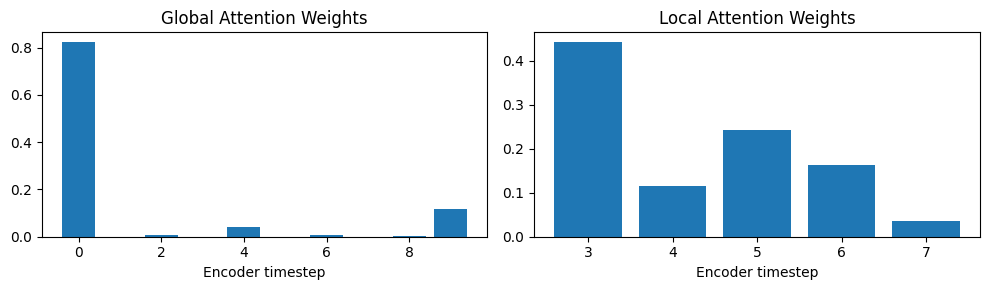

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# Encoder hidden states (batch_size=1, seq_len=10, hidden_dim=8)
encoder_outputs = torch.randn(1, 10, 8)

# Decoder hidden state at time t
decoder_hidden = torch.randn(1, 8)

class GlobalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(GlobalAttention, self).__init__()
        self.W_a = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # Transform encoder states
        transformed_enc = self.W_a(encoder_outputs)  # [1, 10, 8]
        decoder_expanded = decoder_hidden.unsqueeze(1)  # [1, 1, 8]

        # Compute similarity (dot product)
        scores = torch.bmm(decoder_expanded, transformed_enc.transpose(1, 2))  # [1, 1, 10]
        scores = scores.squeeze(1)

        # Softmax across all encoder states
        attn_weights = F.softmax(scores, dim=-1)  # [1, 10]

        # Weighted sum
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_weights

class LocalAttention(nn.Module):
    def __init__(self, hidden_dim, window_size=3):
        super(LocalAttention, self).__init__()
        self.W_a = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_p = nn.Linear(hidden_dim, hidden_dim)
        self.v_p = nn.Linear(hidden_dim, 1, bias=False)
        self.window_size = window_size

    def forward(self, decoder_hidden, encoder_outputs):
        batch, seq_len, hidden_dim = encoder_outputs.shape

        # Step 1: Predict center position p_t
        p_t = seq_len * torch.sigmoid(self.v_p(torch.tanh(self.W_p(decoder_hidden))))
        p_t = p_t.squeeze().item()

        # Step 2: Define window around p_t
        start = int(max(0, math.floor(p_t - self.window_size)))
        end = int(min(seq_len, math.ceil(p_t + self.window_size)))

        local_enc = encoder_outputs[:, start:end, :]
        transformed_enc = self.W_a(local_enc)
        decoder_expanded = decoder_hidden.unsqueeze(1)

        # Step 3: Compute attention within window
        scores = torch.bmm(decoder_expanded, transformed_enc.transpose(1, 2)).squeeze(1)
        attn_weights = F.softmax(scores, dim=-1)

        # Step 4: Compute Gaussian bias
        positions = torch.arange(start, end).float()
        gauss = torch.exp(-((positions - p_t) ** 2) / (2 * self.window_size ** 2))
        gauss = gauss / gauss.sum()

        attn_weights = attn_weights * gauss
        attn_weights = attn_weights / attn_weights.sum()

        # Step 5: Compute local context
        context = torch.bmm(attn_weights.unsqueeze(1), local_enc).squeeze(1)
        return context, attn_weights, (start, end, p_t)

global_attn = GlobalAttention(hidden_dim=8)
local_attn = LocalAttention(hidden_dim=8, window_size=2)

global_context, global_weights = global_attn(decoder_hidden, encoder_outputs)
local_context, local_weights, window_info = local_attn(decoder_hidden, encoder_outputs)

print("Global context shape:", global_context.shape)
print("Local context shape:", local_context.shape)
print("Window:", window_info)


import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.title("Global Attention Weights")
plt.bar(range(10), global_weights.squeeze().detach().numpy())
plt.xlabel("Encoder timestep")

plt.subplot(1,2,2)
plt.title("Local Attention Weights")
plt.bar(range(window_info[0], window_info[1]), local_weights.squeeze().detach().numpy())
plt.xlabel("Encoder timestep")
plt.tight_layout()
plt.show()



---

#### Hard vs Soft Attention

| Type               | Description                                   | Differentiability                                   |
| ------------------ | --------------------------------------------- | --------------------------------------------------- |
| **Soft Attention** | Uses softmax → weighted average of all inputs | ✅ Differentiable (trainable via backprop)           |
| **Hard Attention** | Chooses one specific input (argmax)           | ❌ Non-differentiable (needs reinforcement learning) |

Soft attention = smooth focus
Hard attention = discrete focus (like human eye fixations)

##### Demonstration


Soft Context Shape: torch.Size([1, 8])
Hard Context Shape: torch.Size([1, 8])
Hard Attention Picked Index: 2


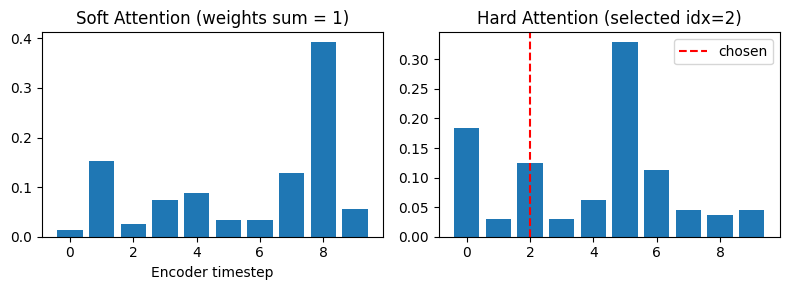

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Encoder outputs: (batch=1, seq_len=10, hidden_dim=8)
encoder_outputs = torch.randn(1, 10, 8)
# Decoder hidden state
decoder_hidden = torch.randn(1, 8)

class SoftAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_a = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # Transform encoder states
        transformed = self.W_a(encoder_outputs)  # [1, seq_len, hidden_dim]
        decoder_expanded = decoder_hidden.unsqueeze(1)  # [1, 1, hidden_dim]

        # Step 1: Compute similarity (dot product)
        scores = torch.bmm(decoder_expanded, transformed.transpose(1, 2)).squeeze(1)  # [1, seq_len]

        # Step 2: Normalize with softmax
        attn_weights = F.softmax(scores, dim=-1)

        # Step 3: Weighted sum (soft focus)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)

        return context, attn_weights


import random

class HardAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_a = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        transformed = self.W_a(encoder_outputs)
        decoder_expanded = decoder_hidden.unsqueeze(1)
        scores = torch.bmm(decoder_expanded, transformed.transpose(1, 2)).squeeze(1)

        # Convert scores to probabilities
        probs = F.softmax(scores, dim=-1)

        # Sample one index (non-differentiable)
        idx = torch.multinomial(probs, num_samples=1).item()

        # Select that one encoder state
        context = encoder_outputs[:, idx, :]
        return context, probs, idx


soft_attn = SoftAttention(hidden_dim=8)
hard_attn = HardAttention(hidden_dim=8)

soft_context, soft_weights = soft_attn(decoder_hidden, encoder_outputs)
hard_context, hard_probs, idx = hard_attn(decoder_hidden, encoder_outputs)

print("Soft Context Shape:", soft_context.shape)
print("Hard Context Shape:", hard_context.shape)
print("Hard Attention Picked Index:", idx)

plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.title("Soft Attention (weights sum = 1)")
plt.bar(range(10), soft_weights.squeeze().detach().numpy())
plt.xlabel("Encoder timestep")

plt.subplot(1,2,2)
plt.title(f"Hard Attention (selected idx={idx})")
plt.bar(range(10), hard_probs.squeeze().detach().numpy())
plt.axvline(idx, color='r', linestyle='--', label='chosen')
plt.legend()
plt.tight_layout()
plt.show()



---

#### Multi-Head Attention (Transformer Attention)

> Core of the Transformer architecture.

##### Mechanism:

Instead of one attention operation, use **multiple heads** (parallel attentions) to learn different aspects of relationships.

$$
\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h)W^O
$$

Each head:
$$
\text{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

##### Advantages:

* Learns multiple semantic relationships (syntax, meaning, position)
* Improves performance and generalization

##### Demonstration

Output shape: torch.Size([1, 6, 16])
Attention weights shape: torch.Size([1, 4, 6, 6])


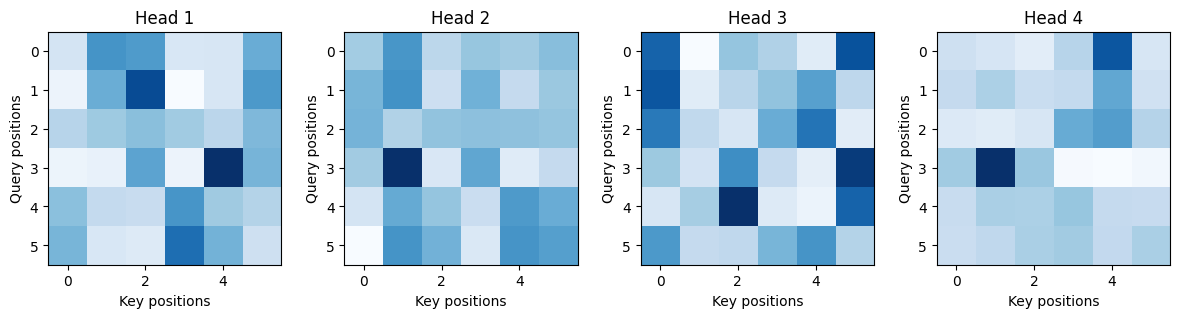

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # Linear projections for Q, K, V
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)  # final linear layer

    def forward(self, Q, K, V):
        batch_size = Q.size(0)

        # 1️⃣ Linear projections
        Q = self.W_q(Q)
        K = self.W_k(K)
        V = self.W_v(V)

        # 2️⃣ Split into heads: (batch, num_heads, seq_len, head_dim)
        def split_heads(x):
            return x.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        Q, K, V = map(split_heads, (Q, K, V))

        # 3️⃣ Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = F.softmax(scores, dim=-1)

        # 4️⃣ Compute context per head
        context = torch.matmul(attn_weights, V)

        # 5️⃣ Concatenate heads
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.embed_dim)

        # 6️⃣ Final linear projection
        output = self.W_o(context)

        return output, attn_weights


torch.manual_seed(0)

batch_size = 1
seq_len = 6
embed_dim = 16
num_heads = 4

# Random input sequence (e.g., embedded words)
x = torch.randn(batch_size, seq_len, embed_dim)

mha = MultiHeadAttention(embed_dim=embed_dim, num_heads=num_heads)
output, attn_weights = mha(x, x, x)

print("Output shape:", output.shape)        # [1, 6, 16]
print("Attention weights shape:", attn_weights.shape)  # [1, 4, 6, 6]


fig, axes = plt.subplots(1, num_heads, figsize=(12, 3))
for i in range(num_heads):
    axes[i].imshow(attn_weights[0, i].detach().numpy(), cmap="Blues")
    axes[i].set_title(f"Head {i+1}")
    axes[i].set_xlabel("Key positions")
    axes[i].set_ylabel("Query positions")
plt.tight_layout()
plt.show()



---

#### Cross-Attention

> Used in encoder–decoder models (Transformers, BERT2BERT, etc.)

* Query (Q): from **decoder**
* Key & Value (K, V): from **encoder**

Allows decoder to “look at” encoder outputs directly (e.g., in translation tasks).

##### Demonstration


Output shape: torch.Size([1, 4, 16])
Attention weights shape: torch.Size([1, 4, 4, 8])


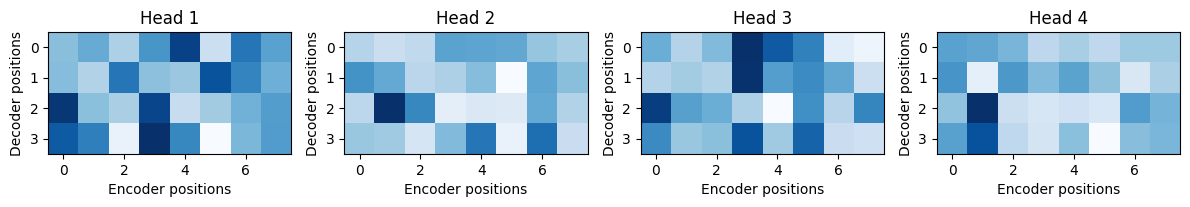

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

class CrossAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)

    def forward(self, decoder_states, encoder_outputs):
        batch_size, tgt_len, _ = decoder_states.shape
        src_len = encoder_outputs.size(1)

        # Linear projections
        Q = self.W_q(decoder_states)
        K = self.W_k(encoder_outputs)
        V = self.W_v(encoder_outputs)

        # Split heads
        def split_heads(x):
            return x.view(batch_size, -1, self.num_heads, self.head_dim).transpose(1, 2)

        Q, K, V = map(split_heads, (Q, K, V))

        # Compute scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = F.softmax(scores, dim=-1)
        context = torch.matmul(attn_weights, V)

        # Combine heads
        context = context.transpose(1, 2).contiguous().view(batch_size, tgt_len, self.embed_dim)
        output = self.W_o(context)

        return output, attn_weights


torch.manual_seed(0)

batch_size = 1
src_len = 8    # encoder sequence length
tgt_len = 4    # decoder sequence length
embed_dim = 16
num_heads = 4

encoder_outputs = torch.randn(batch_size, src_len, embed_dim)   # from encoder
decoder_states  = torch.randn(batch_size, tgt_len, embed_dim)   # from decoder

cross_attn = CrossAttention(embed_dim, num_heads)
output, attn_weights = cross_attn(decoder_states, encoder_outputs)

print("Output shape:", output.shape)            # [1, 4, 16]
print("Attention weights shape:", attn_weights.shape)  # [1, 4, 4, 8] (batch, heads, tgt_len, src_len)



fig, axes = plt.subplots(1, num_heads, figsize=(12, 3))
for i in range(num_heads):
    axes[i].imshow(attn_weights[0, i].detach().numpy(), cmap='Blues')
    axes[i].set_title(f'Head {i+1}')
    axes[i].set_xlabel('Encoder positions')
    axes[i].set_ylabel('Decoder positions')
plt.tight_layout()
plt.show()



---

### **Summary Table**

| Type                   | Key Feature                  | Example Model          |
| ---------------------- | ---------------------------- | ---------------------- |
| Additive (Bahdanau)    | Feedforward score function   | Early NMT              |
| Multiplicative (Luong) | Dot product scoring          | Seq2Seq with attention |
| Self-Attention         | Input attends to itself      | Transformer, BERT, GPT |
| Global Attention       | Full input context           | NMT                    |
| Local Attention        | Limited context window       | Speech models          |
| Hard Attention         | Non-differentiable, discrete | Image captioning       |
| Soft Attention         | Differentiable (softmax)     | Most modern models     |
| Multi-Head Attention   | Parallel attention heads     | Transformer            |
| Cross-Attention        | Decoder attends to encoder   | T5, BART, GPT-4        |

---

**In short**

> Attention mechanisms differ mainly in *what they attend to* (self vs encoder), *how they compute relevance* (additive vs dot-product), and *how many contexts they use* (single vs multi-head).